## **Simple Linear Regression** 
### ($\hat{y} = wX + b$)

Using NumPy and Matplotlib.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

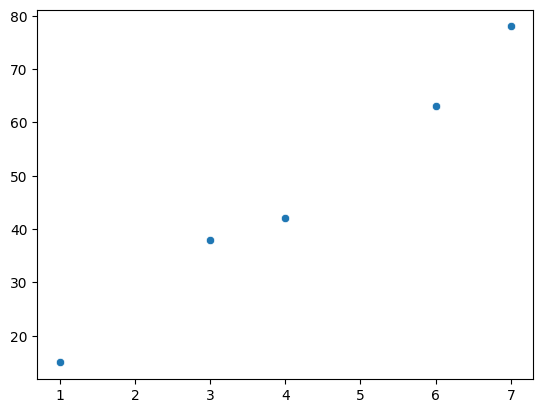

In [3]:
X = np.array([1,3,4,6,7]) # years of experience
y = np.array([15,38,42,63,78]) # salary in thousands

sns.scatterplot(x=X, y=y)

In [4]:
def make_prediction(X, y, w, b):
    m = X.shape[0]

    pred_list = np.zeros((m,))

    for i in range(m):
        pred_list[i] = (w * X[i]) + b

    return pred_list

[0. 0. 0. 0. 0.]


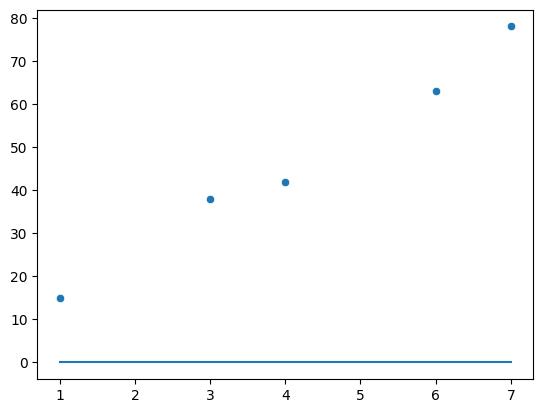

In [5]:
print(make_prediction(X, y, w=0, b=0))

sns.scatterplot(x=X, y=y)
plt.plot(X, make_prediction(X, y, w=0, b=0))

[1. 3. 4. 6. 7.]


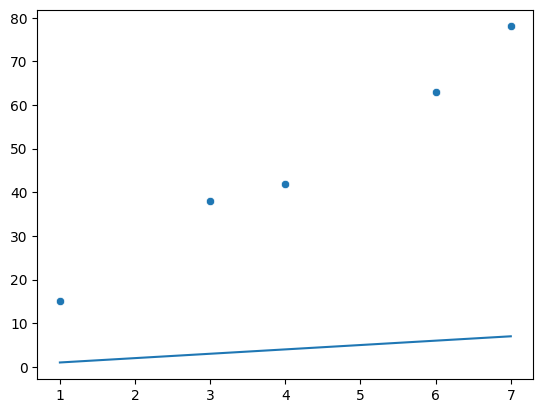

In [6]:
print(make_prediction(X, y, w=1, b=0))

sns.scatterplot(x=X, y=y)
plt.plot(X, make_prediction(X, y, w=1, b=0))

[ 8. 18. 23. 33. 38.]


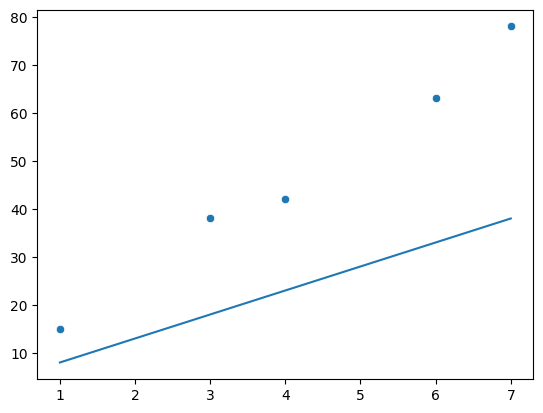

In [7]:
print(make_prediction(X, y, w=5, b=3))

sns.scatterplot(x=X, y=y)
plt.plot(X, make_prediction(X, y, w=5, b=3))

[15. 35. 45. 65. 75.]


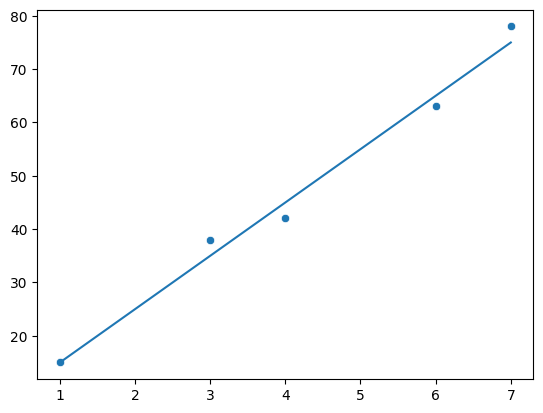

In [8]:
print(make_prediction(X, y, w=10, b=5))

sns.scatterplot(x=X, y=y)
plt.plot(X, make_prediction(X, y, w=10, b=5))

**Implementation of Cost Function** \
Mean Squared Error (MSE): $J(w,b) = \frac {\sum_{i=1}^{m} (\hat{y} - y_{x_i})^2} {2m}$

In [9]:
def compute_cost(X,y,w,b):
    m = X.shape[0]

    squared_err = np.zeros((m,))

    for i in range(m):
        prediction = (w * X[i]) + b
        squared_err[i] = (prediction - y[i])**2
    
    return squared_err.mean()

[0. 0. 0. 0. 0.]


Text(0.5, 1.0, 'Cost: 2697.2 for w=0.0 & b=0.0')

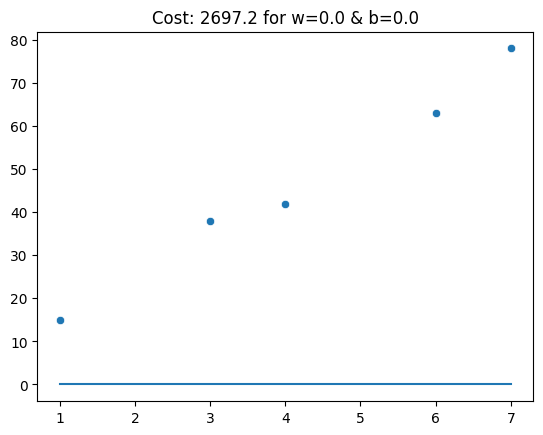

In [10]:
W = 0.0
B = 0.0

print(make_prediction(X, y, w=W, b=B))

sns.scatterplot(x=X, y=y)
plt.plot(X, make_prediction(X, y, w=W, b=B))
plt.title(f"Cost: {compute_cost(X, y, w=W, b=B)} for w={W} & b={B}")

[1. 3. 4. 6. 7.]


Text(0.5, 1.0, 'Cost: 2231.0 for w=1.0 & b=0.0')

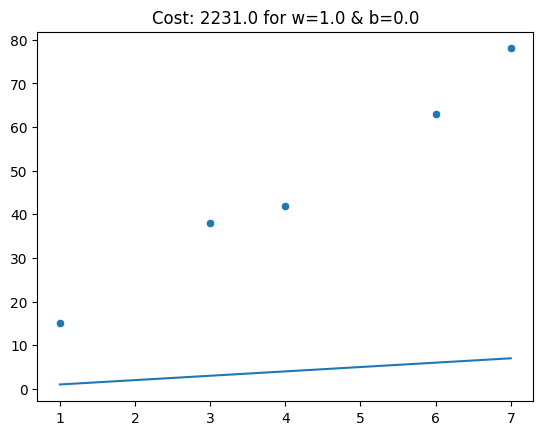

In [11]:
W = 1.0
B = 0.0

print(make_prediction(X, y, w=W, b=B))

sns.scatterplot(x=X, y=y)
plt.plot(X, make_prediction(X, y, w=W, b=B))
plt.title(f"Cost: {compute_cost(X, y, w=W, b=B)} for w={W} & b={B}")

[ 3.  7.  9. 13. 15.]


Text(0.5, 1.0, 'Cost: 1732.6 for w=2.0 & b=1.0')

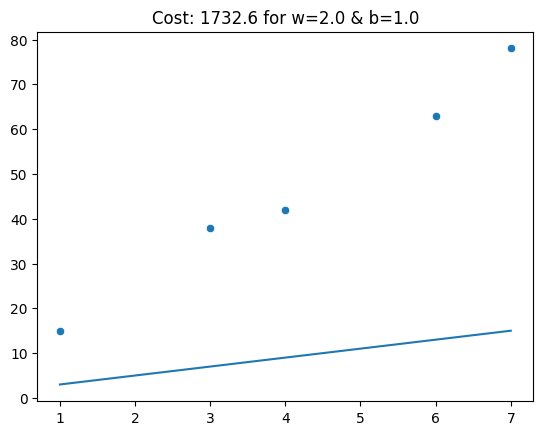

In [12]:
W = 2.0
B = 1.0

print(make_prediction(X, y, w=W, b=B))

sns.scatterplot(x=X, y=y)
plt.plot(X, make_prediction(X, y, w=W, b=B))
plt.title(f"Cost: {compute_cost(X, y, w=W, b=B)} for w={W} & b={B}")

[ 9. 19. 24. 34. 39.]


Text(0.5, 1.0, 'Cost: 616.6 for w=5.0 & b=4.0')

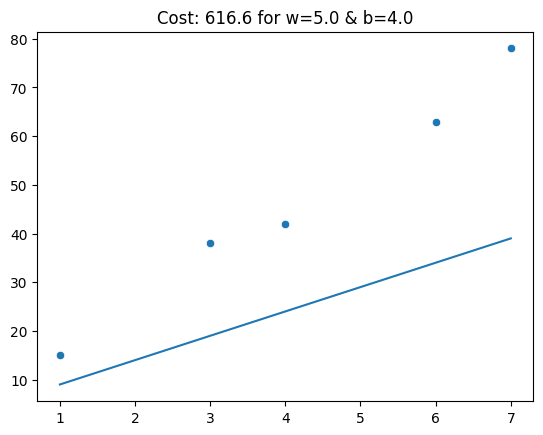

In [13]:
W = 5.0
B = 4.0

print(make_prediction(X, y, w=W, b=B))

sns.scatterplot(x=X, y=y)
plt.plot(X, make_prediction(X, y, w=W, b=B))
plt.title(f"Cost: {compute_cost(X, y, w=W, b=B)} for w={W} & b={B}")

[15. 35. 45. 65. 75.]


Text(0.5, 1.0, 'Cost: 6.2 for w=10.0 & b=5.0')

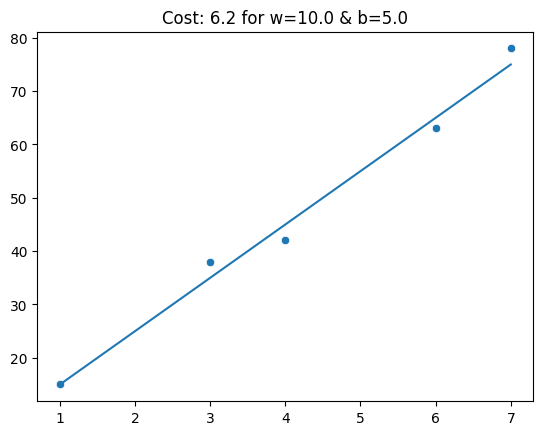

In [14]:
W = 10.0
B = 5.0

print(make_prediction(X, y, w=W, b=B))

sns.scatterplot(x=X, y=y)
plt.plot(X, make_prediction(X, y, w=W, b=B))
plt.title(f"Cost: {compute_cost(X, y, w=W, b=B)} for w={W} & b={B}")

**Cost vs Weights**

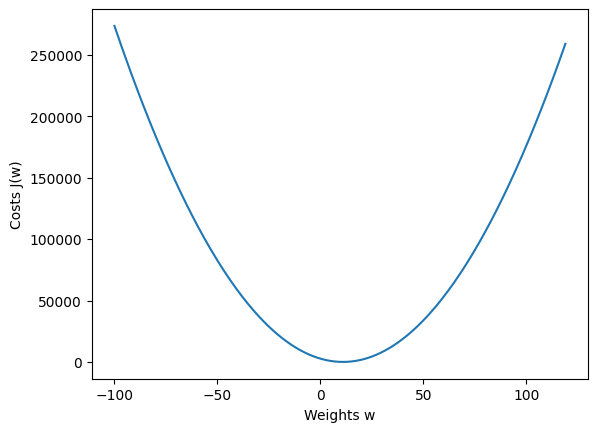

In [15]:
w = []
cost = []

for i in range(-100,120):
    cost_i = compute_cost(X, y, w=i, b=0) # assuming b fixed
    w.append(i)
    cost.append(cost_i)

plt.xlabel("Weights w")
plt.ylabel("Costs J(w)")
plt.plot(w, cost)

---

### **Gradient Descent Algorithm**

Gradient Descent Equation:\
&emsp;$w_{new} = w_{old} - \alpha . \frac{\partial J(w,b)}{\partial w}$\
&emsp;$b_{new} = b_{old} - \alpha . \frac{\partial J(w,b)}{\partial b}$

$\frac {\partial J(w,b)} {\partial w} = \frac {1}{m} . \sum_{i=1}^{m} (\hat{y}-y) . x_i$\
$\frac {\partial J(w,b)} {\partial b} = \frac {1}{m} . \sum_{i=1}^{m} (\hat{y}-y)$

In [16]:
def compute_gradient(X,y,w,b):
    m = X.shape[0]

    dj_dw = 0.0
    dj_db = 0.0

    for i in range(m):
        prediction = (w * X[i]) + b
        error = prediction - y[i]

        dj_dw += (error * X[i])
        dj_db += error
    
    return dj_dw/m, dj_db/m

In [17]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha):

    w = w_input; b = b_input

    cost_memo = []
    iter = []

    for i in range(max_iter+1):
        dj_dw, dj_db = compute_gradient(X, y, w, b)

        w = w - (alpha * dj_dw)
        b = b - (alpha * dj_db)

        cost_memo.append(compute_cost(X, y, w, b))
        iter.append(i)

        if i%100 == 0:
            print(f"iteration: {i}, w: {w:.4f}, b: {b:.4f}, dj_dw: {dj_dw:.4f}, dj_db: {dj_db:.4f}, cost: {compute_cost(X, y, w, b):.4f}")

    return w, b, cost_memo, iter

In [18]:
W, B, cost_memo, iteration = gradient_descent(X, y, w_input=0, b_input=0, max_iter=10000, alpha=0.01)

iteration: 0, w: 2.4420, b: 0.4720, dj_dw: -244.2000, dj_db: -47.2000, cost: 1602.2619
iteration: 100, w: 10.5228, b: 2.5435, dj_dw: 0.0882, dj_db: -0.4618, cost: 7.2422
iteration: 200, w: 10.4429, b: 2.9620, dj_dw: 0.0723, dj_db: -0.3787, cost: 6.8784
iteration: 300, w: 10.3774, b: 3.3051, dj_dw: 0.0593, dj_db: -0.3105, cost: 6.6337
iteration: 400, w: 10.3237, b: 3.5865, dj_dw: 0.0486, dj_db: -0.2546, cost: 6.4692
iteration: 500, w: 10.2796, b: 3.8172, dj_dw: 0.0399, dj_db: -0.2088, cost: 6.3586
iteration: 600, w: 10.2435, b: 4.0064, dj_dw: 0.0327, dj_db: -0.1712, cost: 6.2842
iteration: 700, w: 10.2139, b: 4.1616, dj_dw: 0.0268, dj_db: -0.1404, cost: 6.2342
iteration: 800, w: 10.1896, b: 4.2888, dj_dw: 0.0220, dj_db: -0.1151, cost: 6.2006
iteration: 900, w: 10.1697, b: 4.3931, dj_dw: 0.0180, dj_db: -0.0944, cost: 6.1780
iteration: 1000, w: 10.1533, b: 4.4787, dj_dw: 0.0148, dj_db: -0.0774, cost: 6.1628
iteration: 1100, w: 10.1400, b: 4.5488, dj_dw: 0.0121, dj_db: -0.0635, cost: 6.152

10.078947369724624 4.868421045802798
[14.94736842 35.10526315 45.18421052 65.34210526 75.42105263]


Text(0.5, 1.0, 'Cost: 6.1316 for w=10.0789 & b=4.8684')

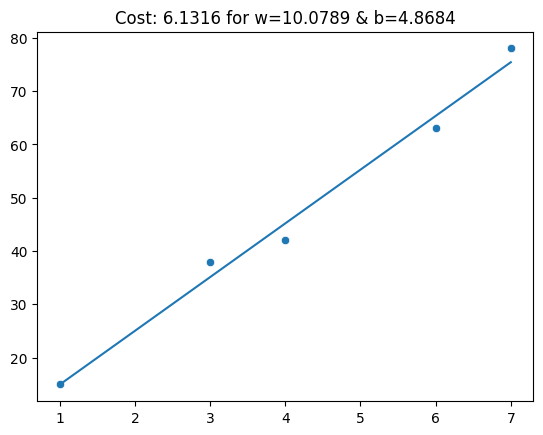

In [19]:
print(W,B)

print(make_prediction(X, y, w=W, b=B))

sns.scatterplot(x=X, y=y)
plt.plot(X, make_prediction(X, y, w=W, b=B))
plt.title(f"Cost: {compute_cost(X, y, w=W, b=B):.4f} for w={W:.4f} & b={B:.4f}")

Text(0, 0.5, 'cost value')

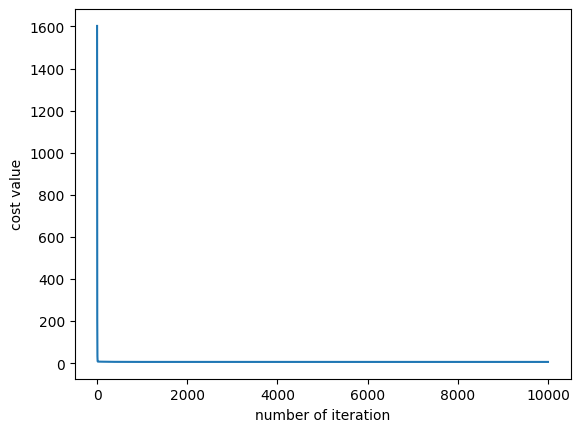

In [20]:
plt.plot(iteration, cost_memo)

plt.xlabel("number of iteration")
plt.ylabel("cost value")

Text(0, 0.5, 'cost value')

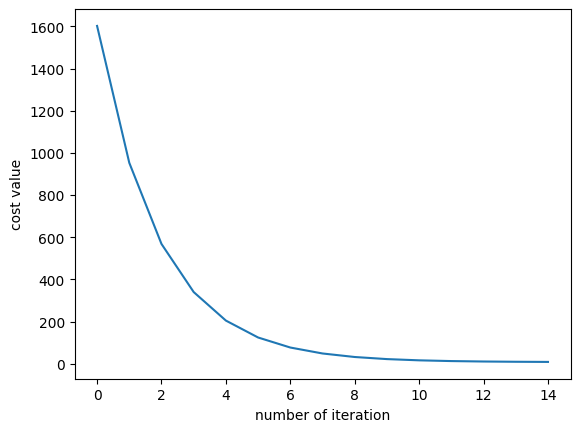

In [23]:
plt.plot(iteration[:15], cost_memo[:15])

plt.xlabel("number of iteration")
plt.ylabel("cost value")

---
---